# 气候可视化 - 温度分析

包含7个精选温度图表

---

## 环境设置

In [1]:
# 导入库
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 中文字体
plt.rcParams['font.sans-serif'] = ['STHeiti', 'PingFang SC', 'Hiragino Sans GB']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['savefig.dpi'] = 300

# 配色
sns.set_style('whitegrid')

# 输出目录
OUT_DIR = Path('output/figures')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('✓ 环境完成')

✓ 环境完成


## 数据加载

In [2]:
import sys
sys.path.append('code')
from data_loader import ClimateDataLoader

loader = ClimateDataLoader(data_dir='data/raw')
df_global = loader.load_global_temperatures()
df_country = loader.load_country_temperatures()
df_city = loader.load_city_temperatures(major_cities_only=True)

print('✅ 数据加载完成')

正在加载全球温度数据: data/raw/GlobalTemperatures.csv
✓ 加载完成：3192 条记录
正在加载国家温度数据: data/raw/GlobalLandTemperaturesByCountry.csv
✓ 加载完成：577462 条记录
  国家数量: 243
正在加载主要城市温度数据: data/raw/GlobalLandTemperaturesByMajorCity.csv
✓ 加载完成：239177 条记录
  城市数量: 100
  国家数量: 49
✅ 数据加载完成


---

## 图表 1: 温度趋势带状图

全球温度变化，带置信区间

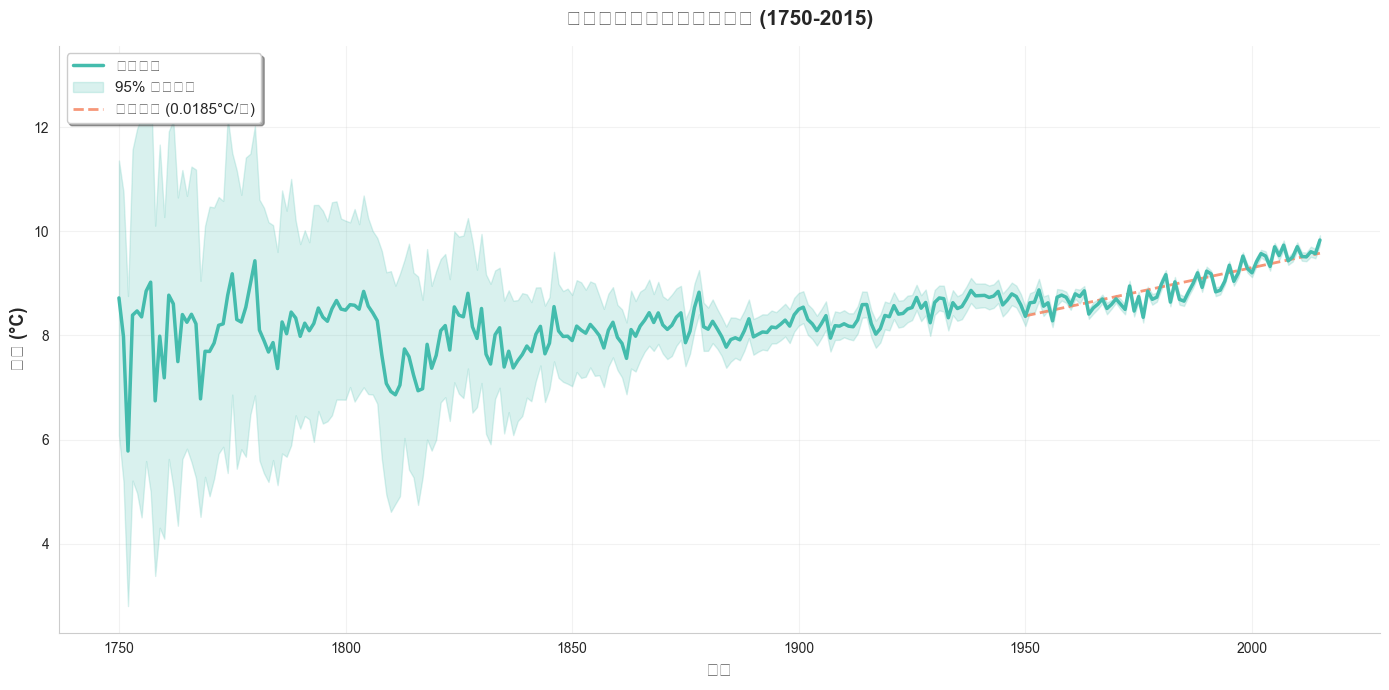

✓ 图表1完成


In [3]:
# 图表1: 温度趋势带状图
df_yearly = df_global.groupby('year').agg({
    'LandAverageTemperature': 'mean',
    'LandAverageTemperatureUncertainty': 'mean'
}).reset_index().dropna()

fig, ax = plt.subplots(figsize=(14, 7))

# 主线
colors = sns.color_palette('mako', n_colors=10)
ax.plot(df_yearly['year'], df_yearly['LandAverageTemperature'],
       linewidth=2.5, color=colors[7], label='全球温度', zorder=3)

# 置信带
ax.fill_between(df_yearly['year'],
    df_yearly['LandAverageTemperature'] - df_yearly['LandAverageTemperatureUncertainty'],
    df_yearly['LandAverageTemperature'] + df_yearly['LandAverageTemperatureUncertainty'],
    alpha=0.2, color=colors[7], label='95% 置信区间')

# 1950后趋势线
recent = df_yearly[df_yearly['year'] >= 1950]
z = np.polyfit(recent['year'], recent['LandAverageTemperature'], 1)
p = np.poly1d(z)
rocket = sns.color_palette('rocket', n_colors=10)
ax.plot(recent['year'], p(recent['year']), '--',
       linewidth=2, color=rocket[7], label=f'加速趋势 ({z[0]:.4f}°C/年)', alpha=0.8)

ax.set_xlabel('年份', fontsize=13, weight='bold')
ax.set_ylabel('温度 (°C)', fontsize=13, weight='bold')
ax.set_title('全球陆地平均温度长期趋势 (1750-2015)', fontsize=15, weight='bold', pad=15)
ax.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
ax.grid(True, alpha=0.25)
sns.despine()

plt.tight_layout()
plt.savefig(OUT_DIR / '01_temperature_bands.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ 图表1完成')

---

## 图表 2: 全球温度趋势

包含置信区间和趋势线

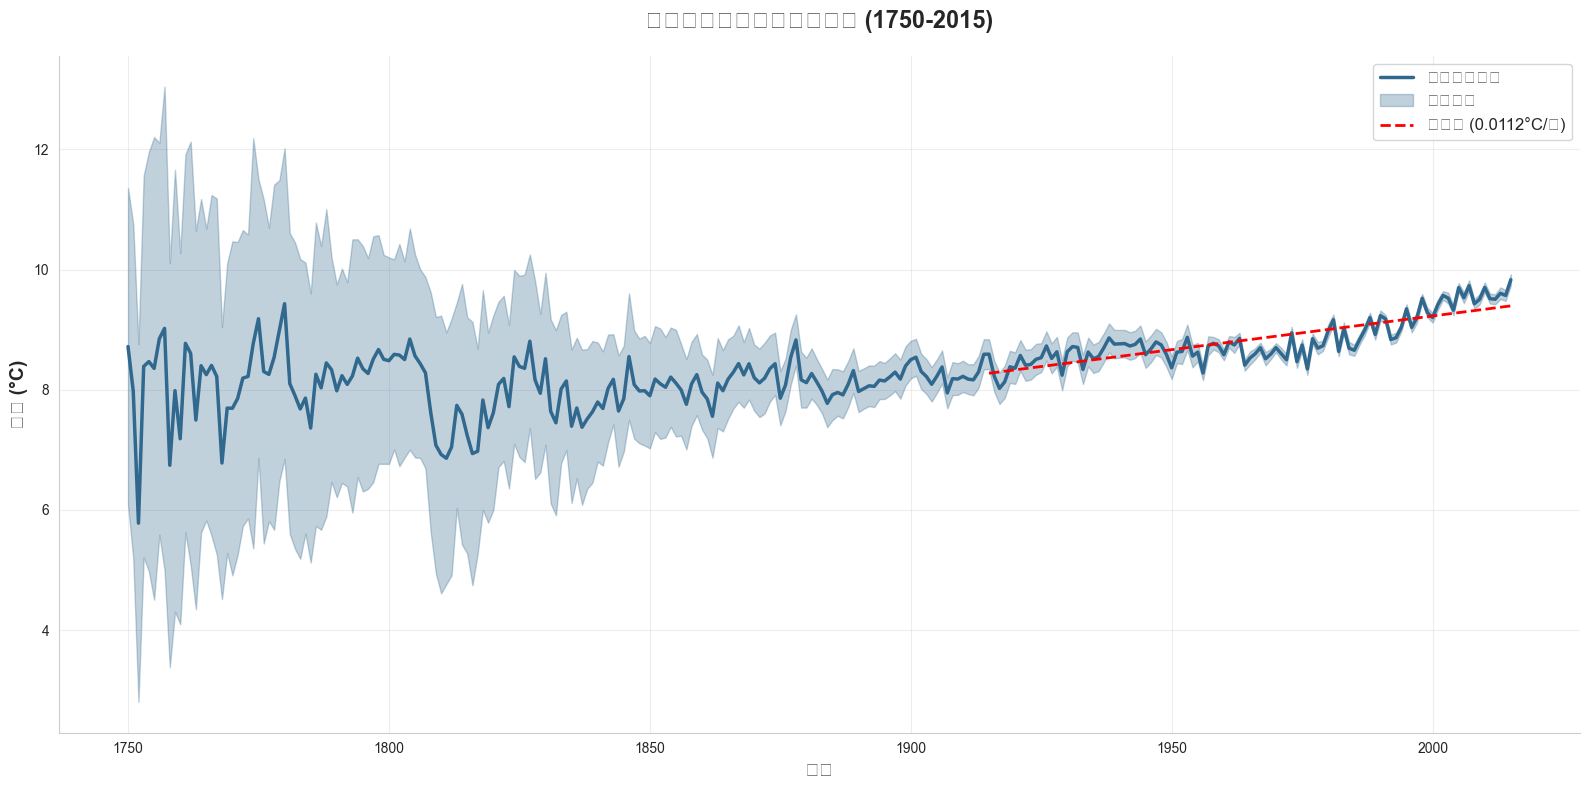

✓ 图表2完成


In [4]:
# 图表2: 全球温度趋势
fig, ax = plt.subplots(figsize=(16, 8))

viridis = sns.color_palette('viridis', 2)
ax.plot(df_yearly['year'], df_yearly['LandAverageTemperature'],
       linewidth=2.5, color=viridis[0], label='陆地平均温度')

ax.fill_between(df_yearly['year'],
    df_yearly['LandAverageTemperature'] - df_yearly['LandAverageTemperatureUncertainty'],
    df_yearly['LandAverageTemperature'] + df_yearly['LandAverageTemperatureUncertainty'],
    alpha=0.3, color=viridis[0], label='置信区间')

# 最近100年趋势
recent_df = df_yearly[df_yearly['year'] >= df_yearly['year'].max() - 100]
z = np.polyfit(recent_df['year'], recent_df['LandAverageTemperature'], 1)
p = np.poly1d(z)
ax.plot(recent_df['year'], p(recent_df['year']), 'r--',
       linewidth=2, label=f'趋势线 ({z[0]:.4f}°C/年)')

ax.set_xlabel('年份', fontsize=14, weight='bold')
ax.set_ylabel('温度 (°C)', fontsize=14, weight='bold')
ax.set_title('全球陆地平均温度变化趋势 (1750-2015)', fontsize=17, weight='bold', pad=20)
ax.legend(fontsize=12, frameon=True)
ax.grid(True, alpha=0.35)
sns.despine()

plt.tight_layout()
plt.savefig(OUT_DIR / '01_global_temperature_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ 图表2完成')

---

## 图表 3: 温度变化速率

10年滑动窗口分析

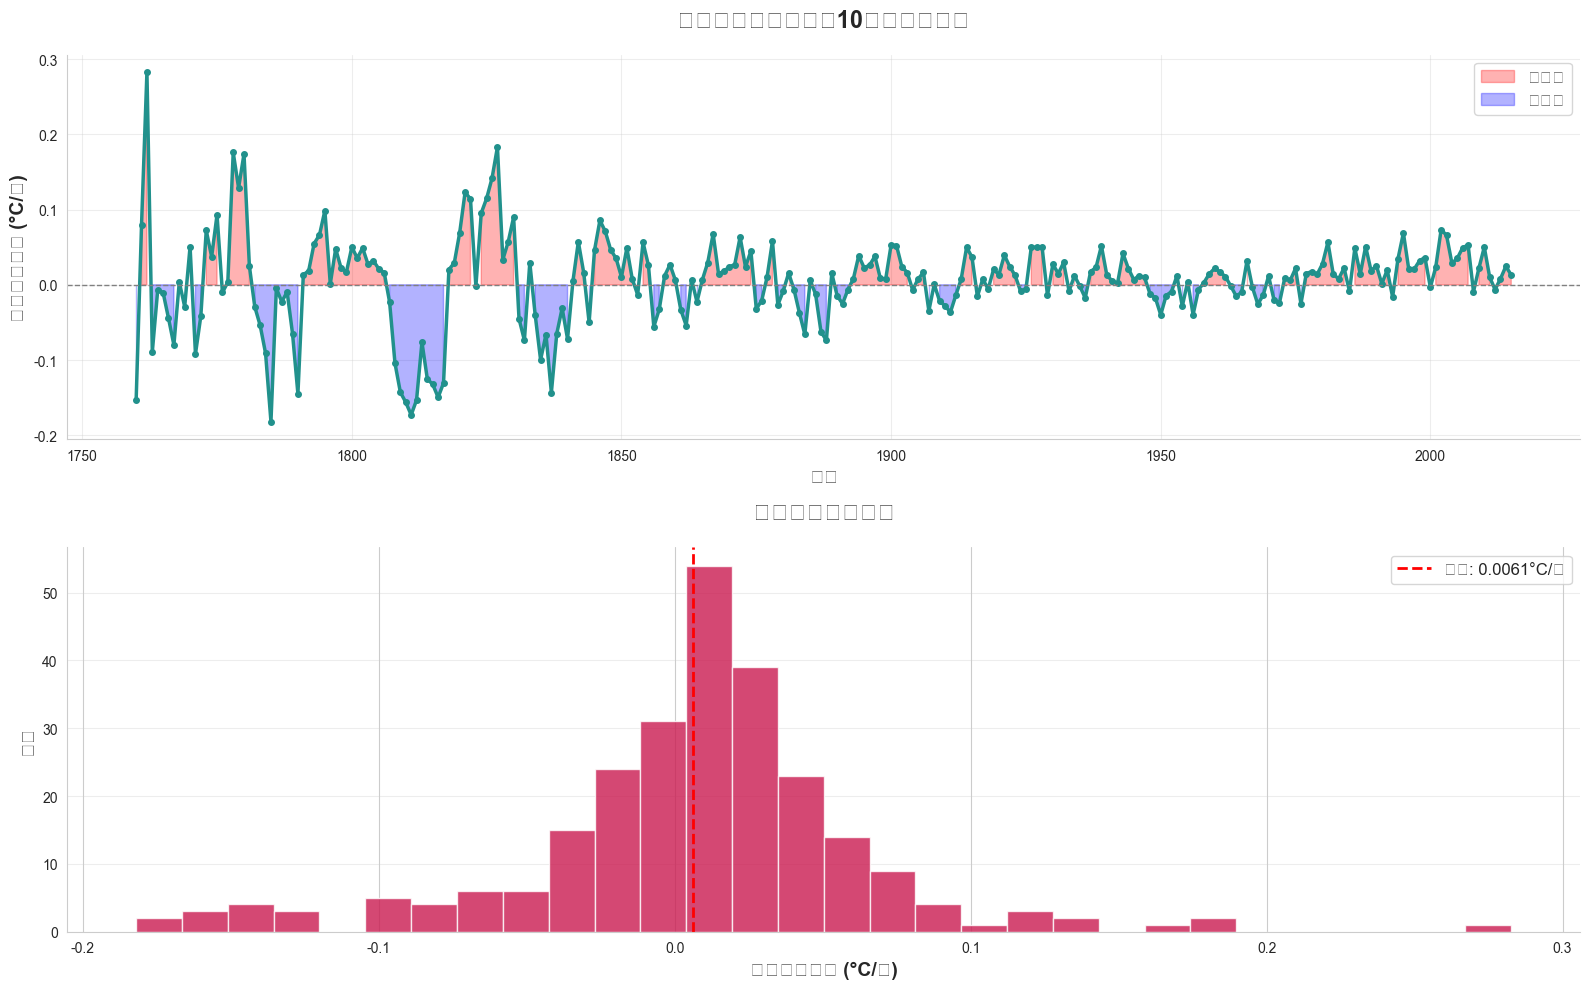

✓ 图表3完成


In [5]:
# 图表3: 温度变化速率
window = 10
change_rates = []
years = []

for i in range(window, len(df_yearly)):
    rate = (df_yearly.iloc[i]['LandAverageTemperature'] - 
            df_yearly.iloc[i-window]['LandAverageTemperature']) / window
    change_rates.append(rate)
    years.append(df_yearly.iloc[i]['year'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# 子图1: 速率时间序列
viridis = sns.color_palette('viridis', 1)
ax1.plot(years, change_rates, linewidth=2.5, color=viridis[0], marker='o', markersize=4)
ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1.fill_between(years, 0, change_rates, where=np.array(change_rates) > 0,
                alpha=0.3, color='red', label='升温期')
ax1.fill_between(years, 0, change_rates, where=np.array(change_rates) < 0,
                alpha=0.3, color='blue', label='降温期')

ax1.set_xlabel('年份', fontsize=14, weight='bold')
ax1.set_ylabel('温度变化速率 (°C/年)', fontsize=14, weight='bold')
ax1.set_title('全球温度变化速率（10年滑动窗口）', fontsize=17, weight='bold', pad=20)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.35)
sns.despine(ax=ax1)

# 子图2: 速率分布
rocket = sns.color_palette('rocket_r', 1)
ax2.hist(change_rates, bins=30, color=rocket[0], edgecolor='white', alpha=0.8)
ax2.axvline(np.mean(change_rates), color='red', linestyle='--', linewidth=2,
           label=f'均值: {np.mean(change_rates):.4f}°C/年')

ax2.set_xlabel('温度变化速率 (°C/年)', fontsize=14, weight='bold')
ax2.set_ylabel('频次', fontsize=14, weight='bold')
ax2.set_title('温度变化速率分布', fontsize=17, weight='bold', pad=20)
ax2.legend(fontsize=12)
ax2.grid(axis='y', alpha=0.35)
sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig(OUT_DIR / '06_temperature_change_rate.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ 图表3完成')

---

## 图表 4: 年代温度对比

4个子图全面分析

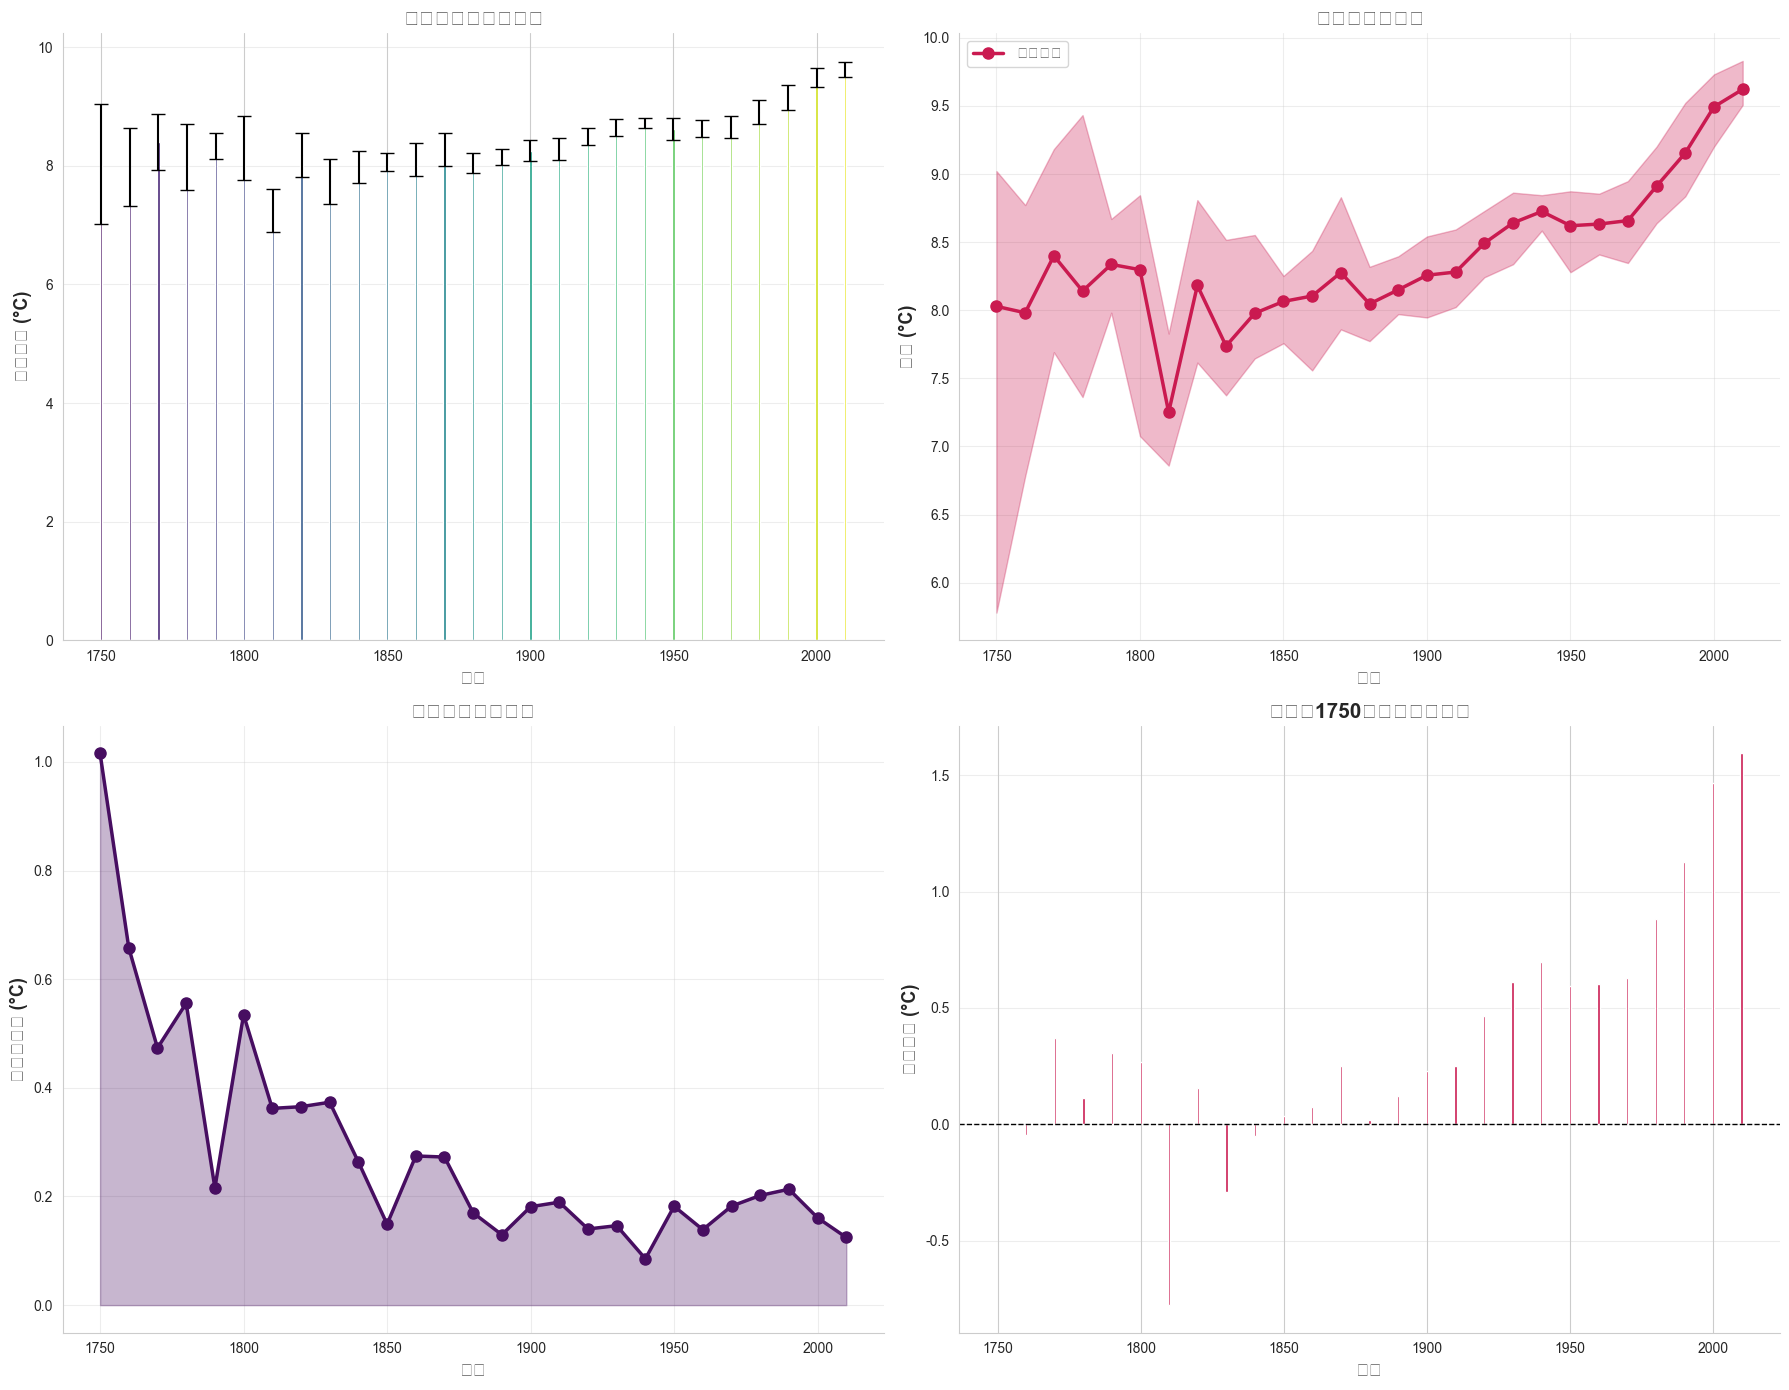

✓ 图表4完成


In [6]:
# 图表4: 年代对比
df_yearly['decade'] = (df_yearly['year'] // 10) * 10
df_decade = df_yearly.groupby('decade')['LandAverageTemperature'].agg(['mean', 'std', 'min', 'max']).reset_index()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# 子图1: 年代平均
viridis = sns.color_palette('viridis', len(df_decade))
bars1 = ax1.bar(df_decade['decade'], df_decade['mean'], color=viridis, edgecolor='white')
ax1.errorbar(df_decade['decade'], df_decade['mean'], yerr=df_decade['std'],
            fmt='none', color='black', capsize=5)
ax1.set_xlabel('年代', fontsize=13, weight='bold')
ax1.set_ylabel('平均温度 (°C)', fontsize=13, weight='bold')
ax1.set_title('各年代平均温度对比', fontsize=15, weight='bold')
ax1.grid(axis='y', alpha=0.35)
sns.despine(ax=ax1)

# 子图2: 温度范围
rocket = sns.color_palette('rocket_r', 1)
ax2.fill_between(df_decade['decade'], df_decade['min'], df_decade['max'],
                alpha=0.3, color=rocket[0])
ax2.plot(df_decade['decade'], df_decade['mean'], 'o-',
        linewidth=2.5, color=rocket[0], markersize=8, label='平均温度')
ax2.set_xlabel('年代', fontsize=13, weight='bold')
ax2.set_ylabel('温度 (°C)', fontsize=13, weight='bold')
ax2.set_title('各年代温度范围', fontsize=15, weight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.35)
sns.despine(ax=ax2)

# 子图3: 标准差
ax3.plot(df_decade['decade'], df_decade['std'], 'o-',
        linewidth=2.5, color=viridis[0], markersize=8)
ax3.fill_between(df_decade['decade'], 0, df_decade['std'], alpha=0.3, color=viridis[0])
ax3.set_xlabel('年代', fontsize=13, weight='bold')
ax3.set_ylabel('温度标准差 (°C)', fontsize=13, weight='bold')
ax3.set_title('各年代温度波动性', fontsize=15, weight='bold')
ax3.grid(True, alpha=0.35)
sns.despine(ax=ax3)

# 子图4: 相对变化
df_decade['change'] = df_decade['mean'] - df_decade.iloc[0]['mean']
bars4 = ax4.bar(df_decade['decade'], df_decade['change'], color=rocket, edgecolor='white')
ax4.axhline(0, color='black', linestyle='--', linewidth=1)
ax4.set_xlabel('年代', fontsize=13, weight='bold')
ax4.set_ylabel('温度变化 (°C)', fontsize=13, weight='bold')
ax4.set_title(f"相对于{int(df_decade.iloc[0]['decade'])}年代的温度变化", fontsize=15, weight='bold')
ax4.grid(axis='y', alpha=0.35)
sns.despine(ax=ax4)

plt.tight_layout()
plt.savefig(OUT_DIR / '12_decade_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ 图表4完成')

---

## 图表 5: TOP25升温最快国家热力图

专业热力图展示

In [8]:
# 图表5: 国家热力图
# 选择TOP25升温最快国家
key_years = [1850, 1900, 1950, 1980, 2000, 2010]

df_2010 = df_country[df_country['year'] == 2010]
df_1850 = df_country[df_country['year'] == 1850]
df_change = df_2010.merge(df_1850, on='Country', suffixes=('_2010', '_1850'))
df_change['change'] = df_change['AverageTemperature_2010'] - df_change['AverageTemperature_1850']
top25 = df_change.nlargest(25, 'change')['Country'].tolist()

# 准备热力图数据
heatmap_data = []
for country in top25:
    temps = []
    for year in key_years:
        df_temp = df_country[(df_country['Country']==country) & (df_country['year']==year)]
       temps.append(df_temp['AverageTemperature'].mean() if not df_temp.empty else np.nan)
    heatmap_data.append(temps)

heatmap_df = pd.DataFrame(heatmap_data, index=top25, columns=key_years)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(heatmap_df, cmap='rocket', annot=False, linewidths=1, linecolor='white',
           cbar_kws={'label': '平均温度 (°C)', 'shrink': 0.8}, ax=ax)

ax.set_xlabel('年份', fontsize=12, weight='bold')
ax.set_ylabel('国家', fontsize=12, weight='bold')
ax.set_title('TOP25升温最快国家的温度演变', fontsize=14, weight='bold', pad=15)

plt.tight_layout()
plt.savefig(OUT_DIR / '02_country_heatmap_pro.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ 图表5完成')

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 17)

---

## 图表 6: 纬度带温度分布

小提琴图展示

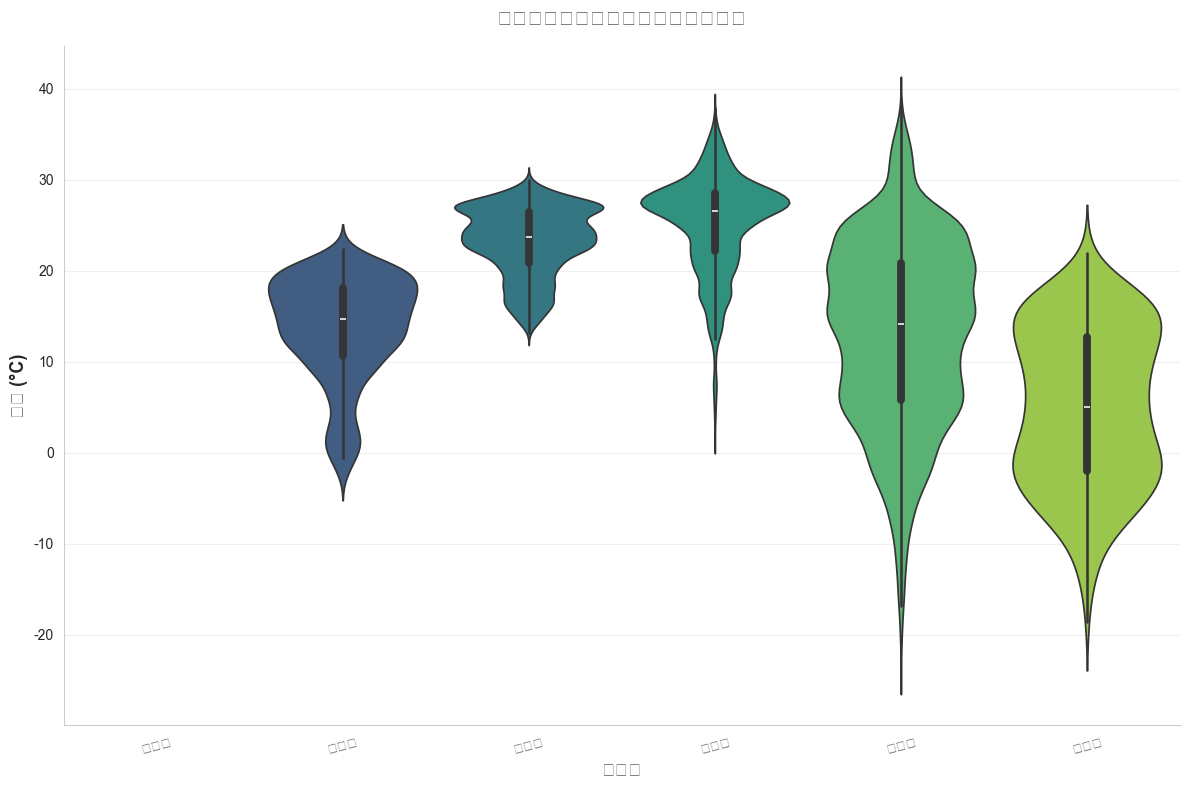

✓ 图表6完成


In [ ]:
# 图表6: 纬度小提琴图
max_year = df_city['year'].max()
df_recent = df_city[df_city['year'] >= max_year - 30].copy()

# 纬度分组
df_recent['latitude_band'] = pd.cut(df_recent['Latitude_num'],
    bins=[-90, -60, -30, 0, 30, 60, 90],
    labels=['极地南', '高纬南', '中纬南', '中纬北', '高纬北', '极地北'])

fig, ax = plt.subplots(figsize=(12, 8))

palette = sns.color_palette('viridis', 6)
sns.violinplot(data=df_recent, x='latitude_band', y='AverageTemperature',
              palette=palette, inner='box', ax=ax)

ax.set_xlabel('纬度带', fontsize=13, weight='bold')
ax.set_ylabel('温度 (°C)', fontsize=13, weight='bold')
ax.set_title('不同纬度带的温度分布（小提琴图）', fontsize=15, weight='bold', pad=15)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15)
sns.despine()

plt.tight_layout()
plt.savefig(OUT_DIR / '03_latitude_violin_pro.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ 图表6完成')

---

## 图表 7: 主要国家温度分布

箱线图展示

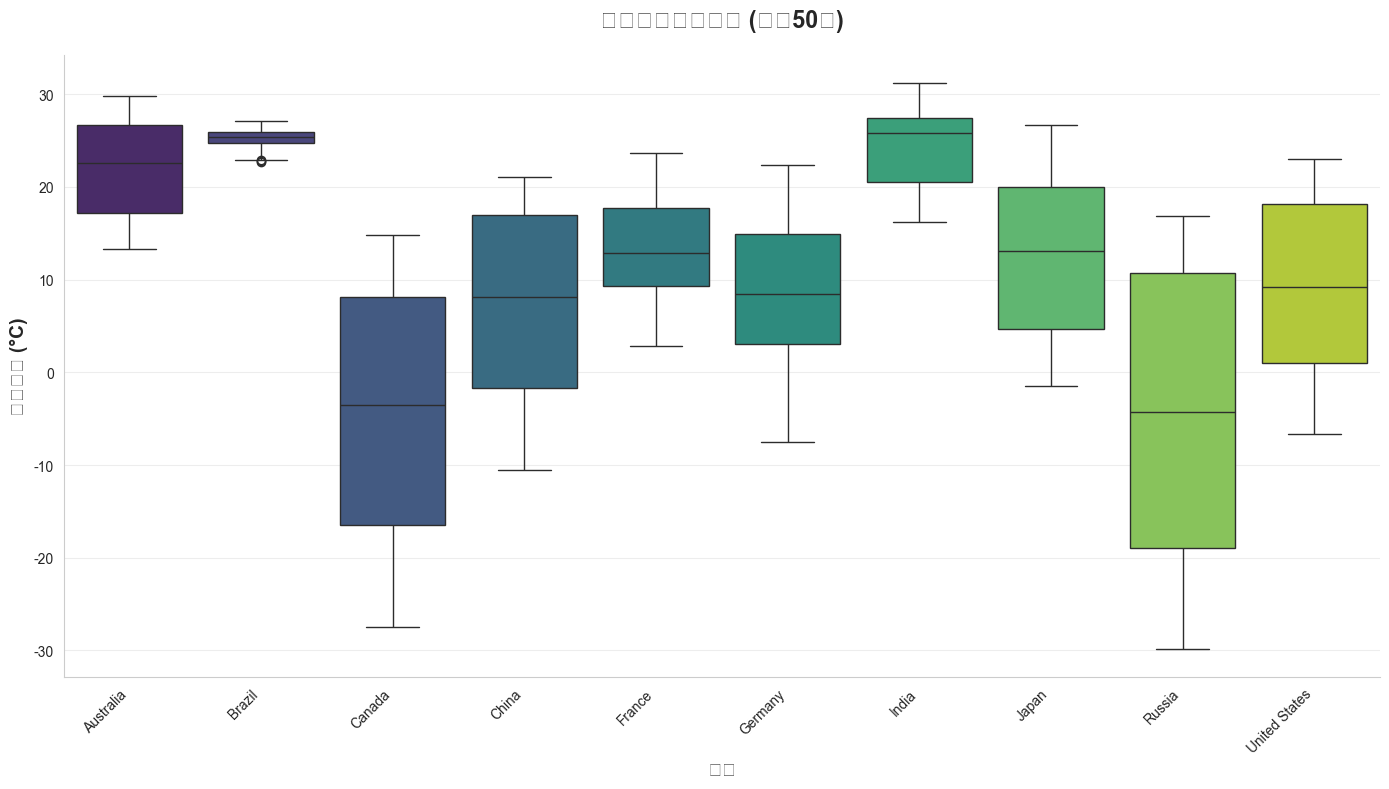

✓ 图表7完成


In [ ]:
# 图表7: 温度分布箱线图
countries = ['China', 'United States', 'Russia', 'India', 'Brazil',
            'Canada', 'Australia', 'Germany', 'France', 'Japan']
df_selected = df_country[df_country['Country'].isin(countries)]

# 最近50年
max_year = df_selected['year'].max()
df_selected = df_selected[df_selected['year'] >= max_year - 50]

fig, ax = plt.subplots(figsize=(14, 8))

viridis = sns.color_palette('viridis', len(countries))
sns.boxplot(data=df_selected, x='Country', y='AverageTemperature',
           palette=viridis, ax=ax)

ax.set_xlabel('国家', fontsize=14, weight='bold')
ax.set_ylabel('平均温度 (°C)', fontsize=14, weight='bold')
ax.set_title('主要国家温度分布 (最近50年)', fontsize=17, weight='bold', pad=20)
ax.grid(axis='y', alpha=0.35)
plt.xticks(rotation=45, ha='right')
sns.despine()

plt.tight_layout()
plt.savefig(OUT_DIR / '05_temperature_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ 图表7完成')